In [380]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [381]:
df = pd.read_csv("../data/raw/unemployment.csv", sep=",")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [382]:
df.shape

(768, 7)

In [383]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [384]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [385]:
df.duplicated().sum()

np.int64(27)

In [386]:
df.drop_duplicates(inplace=True)

In [387]:
df.isna().sum()

Region                                      1
 Date                                       1
 Frequency                                  1
 Estimated Unemployment Rate (%)            1
 Estimated Employed                         1
 Estimated Labour Participation Rate (%)    1
Area                                        1
dtype: int64

In [388]:
df.dropna(inplace=True)

In [389]:
df.shape

(740, 7)

In [390]:
df.to_csv("../data/processed/proper_dataset.csv", index=False)

In [391]:
df_corrected = pd.read_csv("../data/processed/proper_dataset.csv")

In [392]:
df_copy = df_corrected.copy()

In [393]:
df_copy.shape

(740, 7)

In [394]:
#### Data cleaning/processing

In [395]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 64.2 KB


In [396]:
df_copy.columns = df_copy.columns.str.strip()
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 64.2 KB


In [397]:
df_copy["Date"] = pd.to_datetime(df_copy["Date"], dayfirst=True)

In [398]:
df_copy["Year"] = df_copy["Date"].dt.year
df_copy["Month"] = df_copy["Date"].dt.month
df_copy["Quarter"] = df_copy["Date"].dt.quarter

In [399]:
df_copy.columns


Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area',
       'Year', 'Month', 'Quarter'],
      dtype='str')

In [400]:
cols = ['Region', 'Frequency', 'Area']

for i in cols:
    print(f"\nThe unique value in {i} is: {df_copy[i].unique()} \n")


The unique value in Region is: <ArrowStringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str 


The unique value in Frequency is: <ArrowStringArray>
[' Monthly', 'Monthly']
Length: 2, dtype: str 


The unique value in Area is: <ArrowStringArray>
['Rural', 'Urban']
Length: 2, dtype: str 



In [401]:
df_copy["Frequency"] = df_copy["Frequency"].str.strip()

In [402]:
df_copy.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Quarter
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,2
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,2
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,3
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,3
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,3


In [403]:
# Freq = all monthly
# Area = rural and urban 

#Feature engineering : PostCovid using Date 2020-03-20 (Started lockdown from here in Nepal so assuming same in india)

In [404]:
df_copy["Post_COVID"] = (df_copy["Date"] >= '2020-03-20').astype(int)

In [405]:
df_copy = df_copy.drop("Date", axis=1)

In [406]:
df_copy.head()

,Region,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Quarter,Post_COVID
0,Andhra Pradesh,Monthly,3.65,11999139.0,43.24,Rural,2019,5,2,0
1,Andhra Pradesh,Monthly,3.05,11755881.0,42.05,Rural,2019,6,2,0
2,Andhra Pradesh,Monthly,3.75,12086707.0,43.50,Rural,2019,7,3,0
3,Andhra Pradesh,Monthly,3.32,12285693.0,43.97,Rural,2019,8,3,0
4,Andhra Pradesh,Monthly,5.17,12256762.0,44.68,Rural,2019,9,3,0


In [407]:
### Data visualization

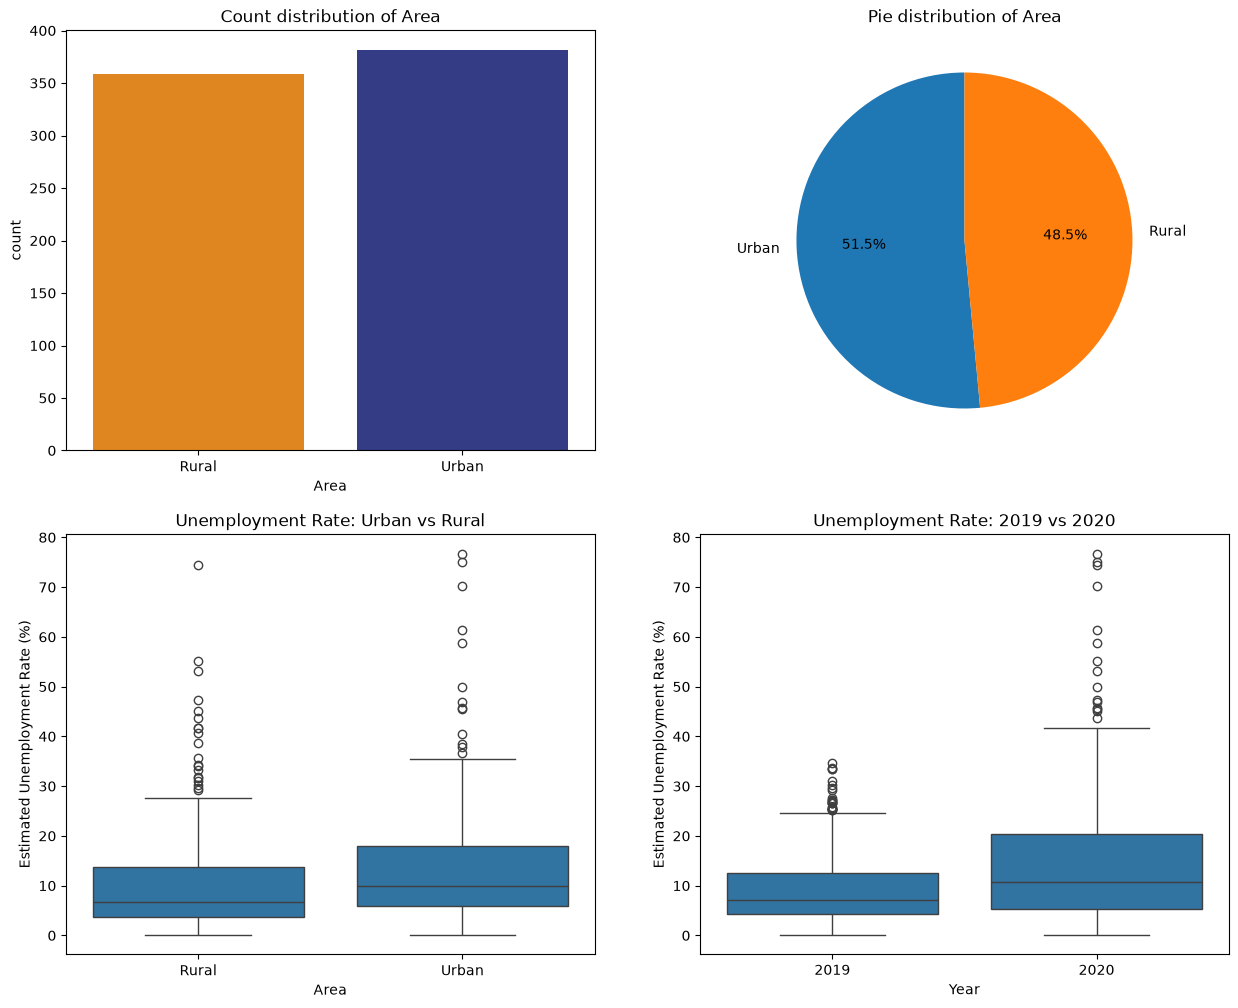

In [408]:
fig, axes = plt.subplots(2,2, figsize=(15,12))
axes= axes.flatten()

sns.countplot(x="Area", data=df_copy, ax=axes[0], palette=["#ff8800", "#263291"])
axes[0].set_title("Count distribution of Area")

axes[1].pie(x=df_copy["Area"].value_counts(), labels=(df_copy["Area"].value_counts()).index, autopct= "%1.1f%%", startangle=90 )
axes[1].set_title("Pie distribution of Area")

sns.boxplot(
    data=df_copy,
    x="Area",
    y="Estimated Unemployment Rate (%)",
    ax=axes[2]
)
axes[2].set_title("Unemployment Rate: Urban vs Rural")

sns.boxplot(
    data=df_copy,
    x="Year",
    y="Estimated Unemployment Rate (%)",
    ax=axes[3]
)
axes[3].set_title("Unemployment Rate: 2019 vs 2020")

plt.show()

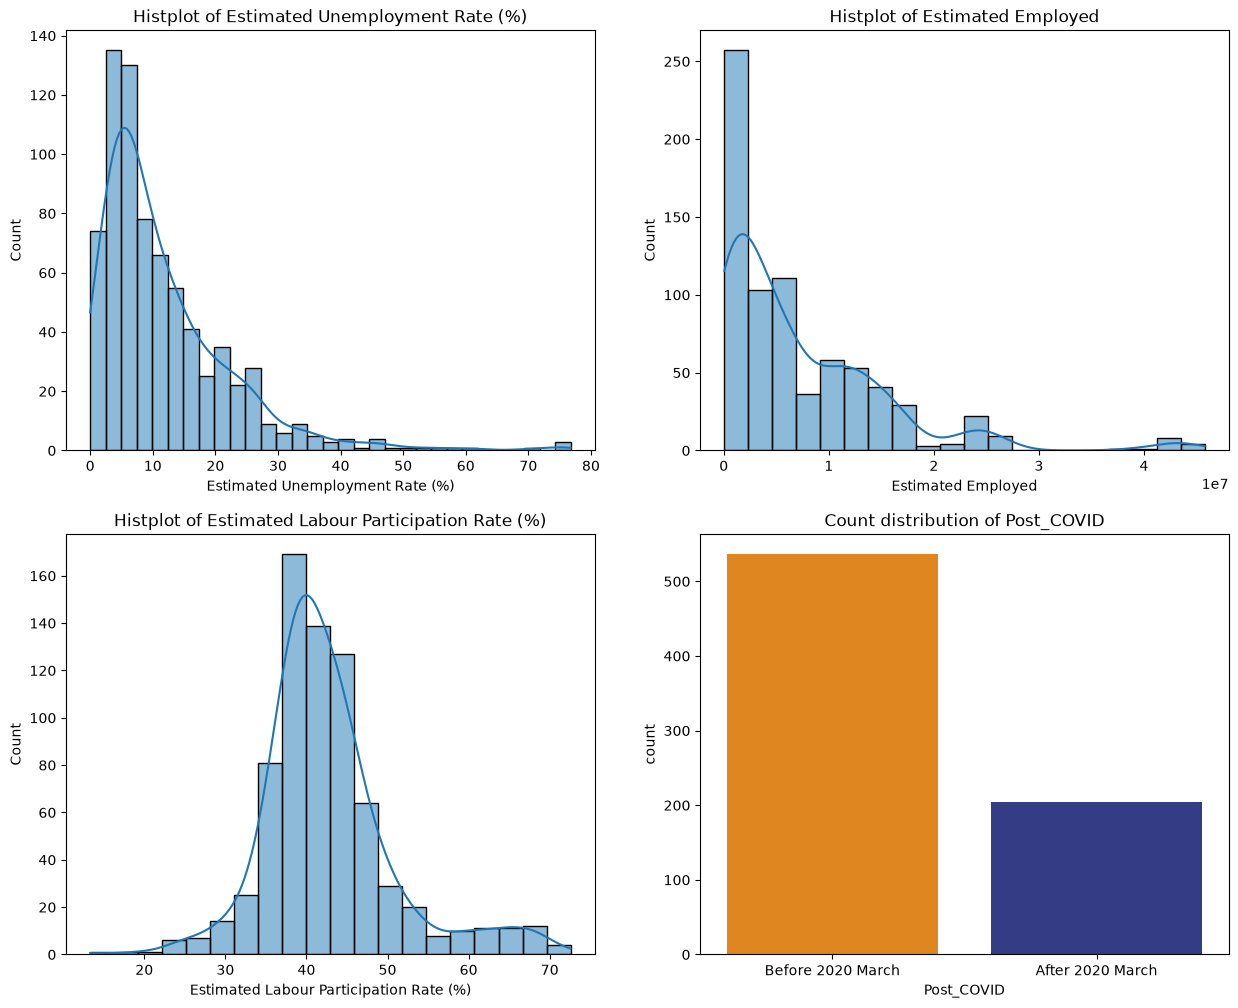

In [409]:
fig, axes = plt.subplots(2,2, figsize=(15,12))
axes= axes.flatten()

sns.histplot(x="Estimated Unemployment Rate (%)", ax=axes[0], data=df_copy, kde=True)
axes[0].set_title("Histplot of Estimated Unemployment Rate (%)")

sns.histplot(x="Estimated Employed", ax=axes[1], data=df_copy, kde=True, bins=20)
axes[1].set_title("Histplot of Estimated Employed")

sns.histplot(x="Estimated Labour Participation Rate (%)", ax=axes[2], data=df_copy, kde=True, bins=20)
axes[2].set_title("Histplot of Estimated Labour Participation Rate (%)")

sns.countplot(x="Post_COVID", data=df_copy, ax=axes[3], palette=["#ff8800", "#263291"])
axes[3].set_title("Count distribution of Post_COVID")
plt.xticks(['0', '1'], labels=["Before 2020 March", "After 2020 March"])

plt.show()

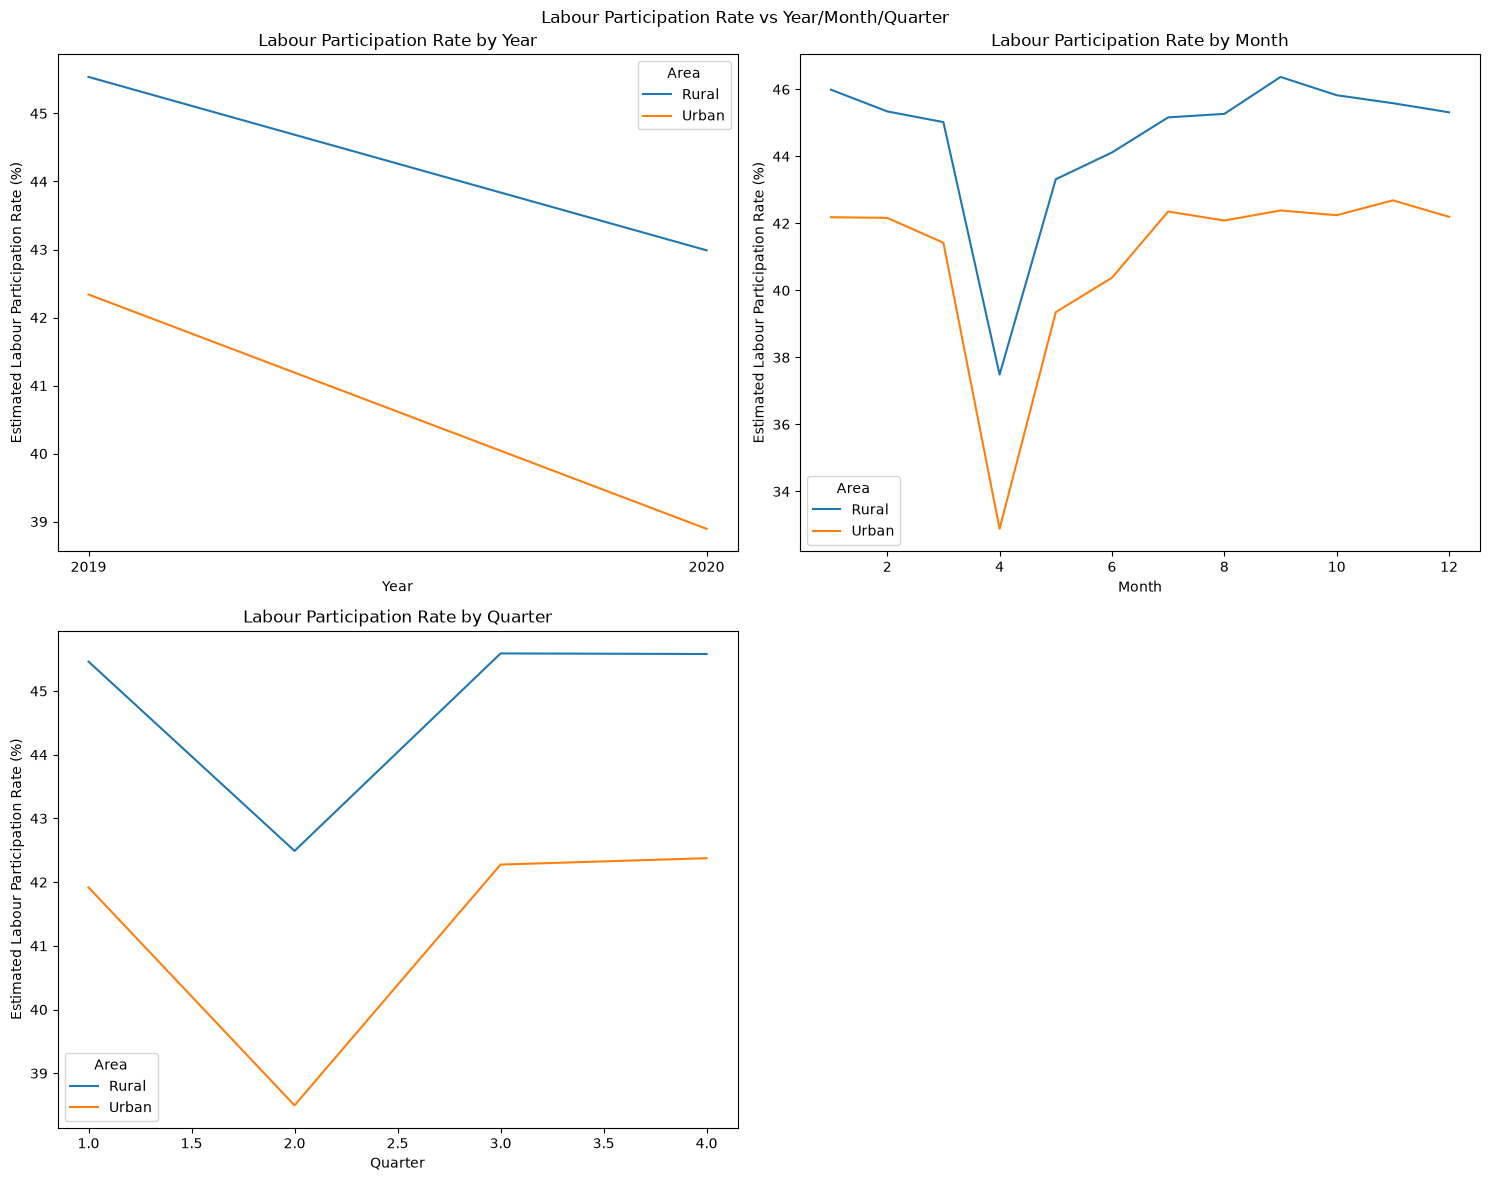

In [410]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

plt.suptitle("Labour Participation Rate vs Year/Month/Quarter")

# Year
sns.lineplot(
    x=df_copy["Year"].astype(str),
    y="Estimated Labour Participation Rate (%)",
    estimator="mean",
    errorbar=None,
    data=df_copy,
    hue="Area",
    ax=axes[0]
)
axes[0].set_title("Labour Participation Rate by Year")

# Month
sns.lineplot(
    x="Month",
    y="Estimated Labour Participation Rate (%)",
    estimator="mean",
    errorbar=None,
    data=df_copy,
    hue="Area",
    ax=axes[1]
)
axes[1].set_title("Labour Participation Rate by Month")

# Quarter
sns.lineplot(
    x="Quarter",
    y="Estimated Labour Participation Rate (%)",
    estimator="mean",
    errorbar=None,
    data=df_copy,
    hue="Area",
    ax=axes[2]
)
axes[2].set_title("Labour Participation Rate by Quarter")

# Remove the unused subplot
fig.delaxes(axes[3])

plt.tight_layout()
plt.show()

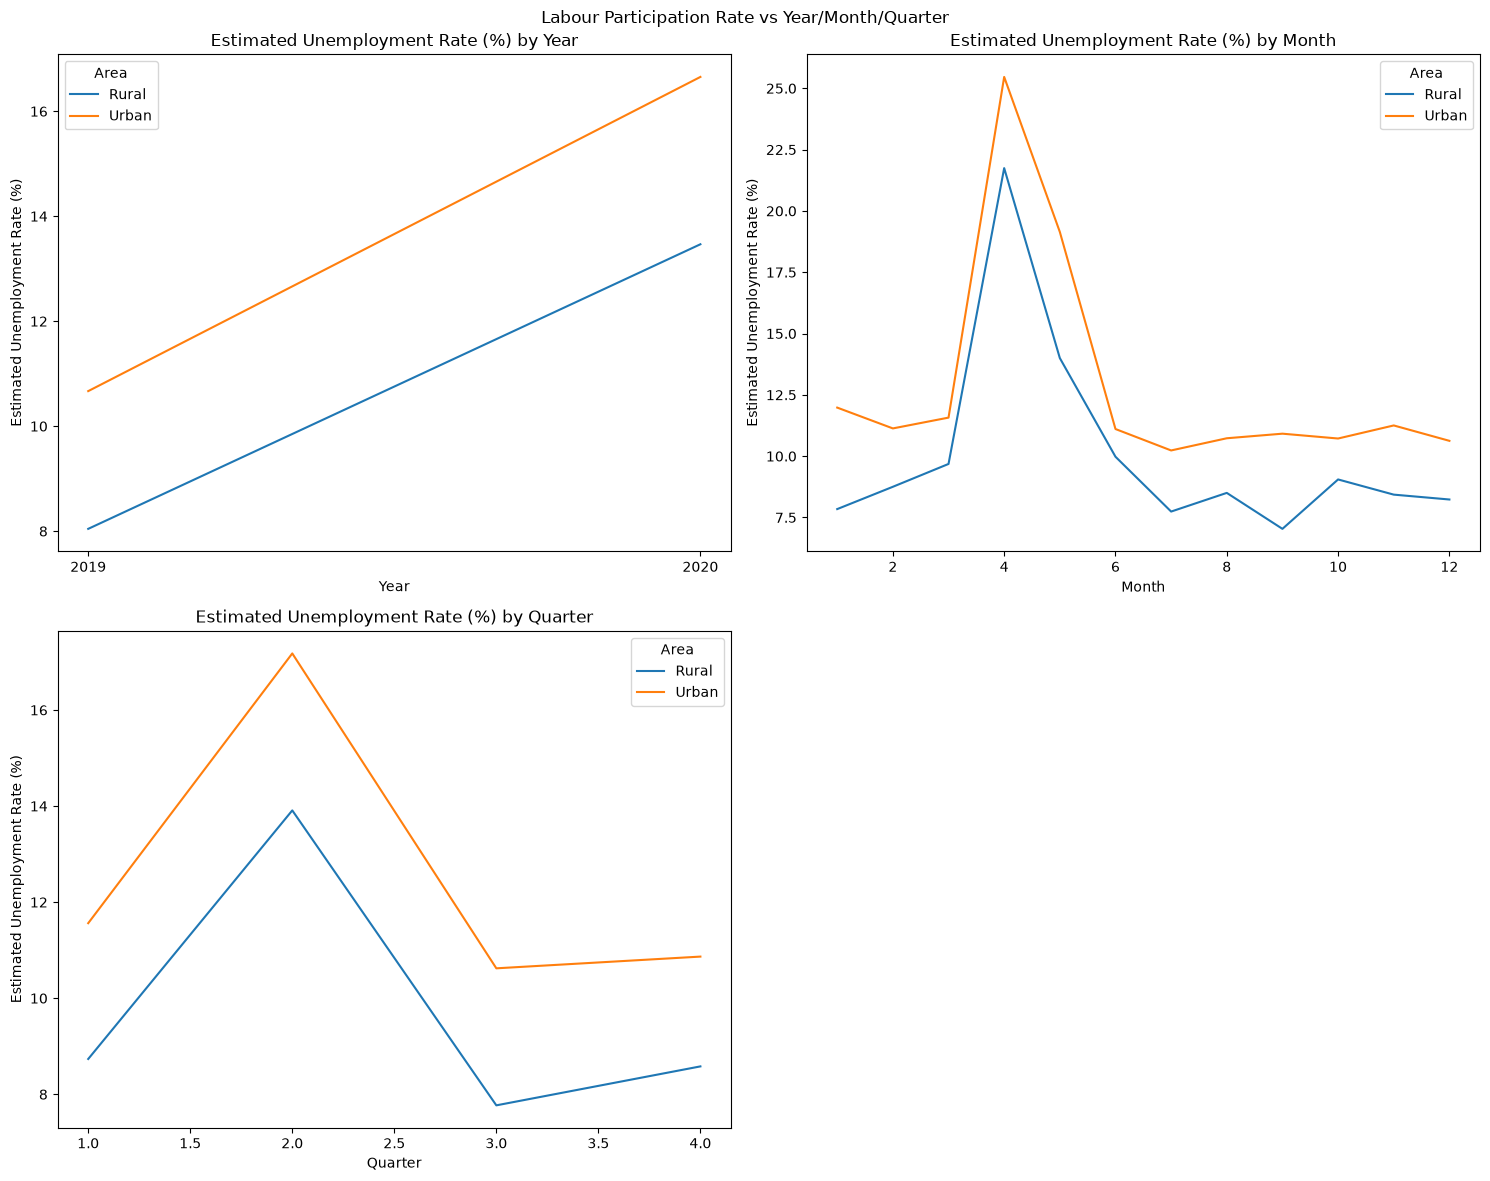

In [411]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

plt.suptitle("Labour Participation Rate vs Year/Month/Quarter")

# Year
sns.lineplot(
    x=df_copy["Year"].astype(str),
    y="Estimated Unemployment Rate (%)",
    estimator="mean",
    errorbar=None,
    data=df_copy,
    hue="Area",
    ax=axes[0]
)
axes[0].set_title("Estimated Unemployment Rate (%) by Year")

# Month
sns.lineplot(
    x="Month",
    y="Estimated Unemployment Rate (%)",
    estimator="mean",
    errorbar=None,
    data=df_copy,
    hue="Area",
    ax=axes[1]
)
axes[1].set_title("Estimated Unemployment Rate (%) by Month")

# Quarter
sns.lineplot(
    x="Quarter",
    y="Estimated Unemployment Rate (%)",
    estimator="mean",
    errorbar=None,
    data=df_copy,
    hue="Area",
    ax=axes[2]
)
axes[2].set_title("Estimated Unemployment Rate (%) by Quarter")

# Remove the unused subplot
fig.delaxes(axes[3])

plt.tight_layout()
plt.show()

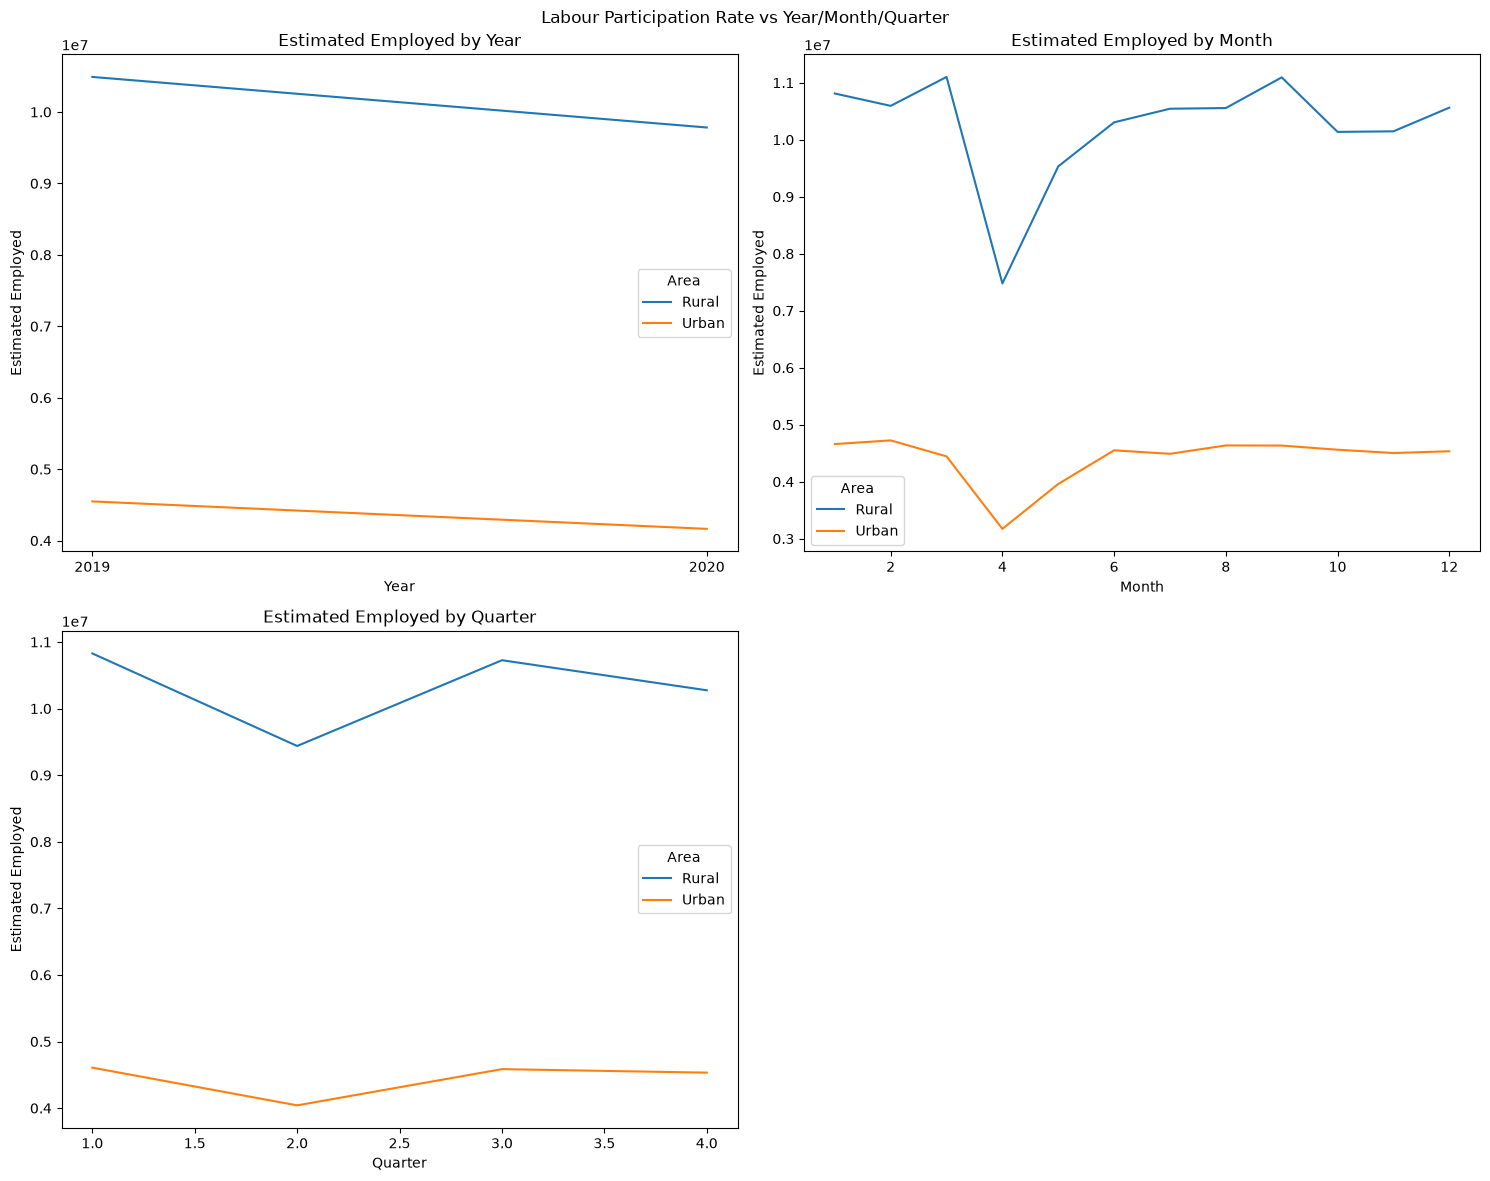

In [412]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

plt.suptitle("Labour Participation Rate vs Year/Month/Quarter")

# Year
sns.lineplot(
    x=df_copy["Year"].astype(str),
    y="Estimated Employed",
    estimator="mean",
    errorbar=None,
    data=df_copy,
    hue="Area",
    ax=axes[0]
)
axes[0].set_title("Estimated Employed by Year")

# Month
sns.lineplot(
    x="Month",
    y="Estimated Employed",
    estimator="mean",
    errorbar=None,
    data=df_copy,
    hue="Area",
    ax=axes[1]
)
axes[1].set_title("Estimated Employed by Month")

# Quarter
sns.lineplot(
    x="Quarter",
    y="Estimated Employed",
    estimator="mean",
    errorbar=None,
    data=df_copy,
    hue="Area",
    ax=axes[2]
)
axes[2].set_title("Estimated Employed by Quarter")

# Remove the unused subplot
fig.delaxes(axes[3])

plt.tight_layout()
plt.show()

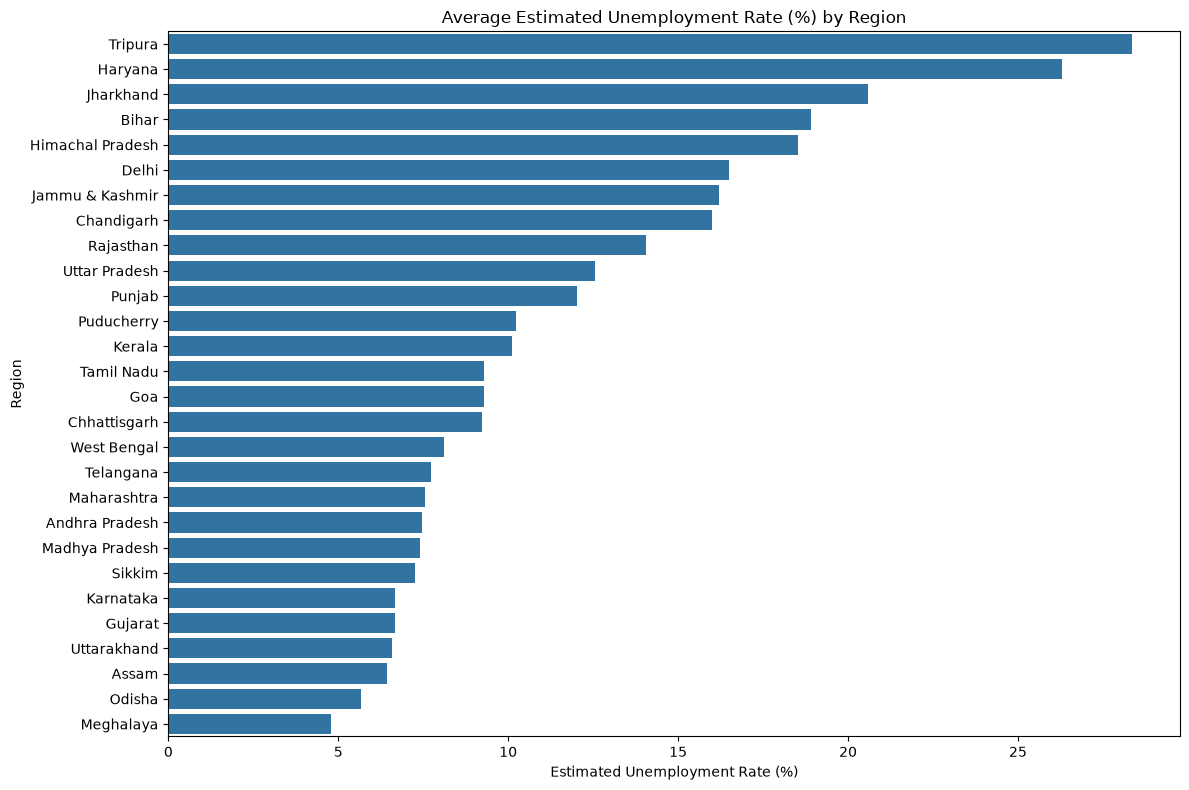

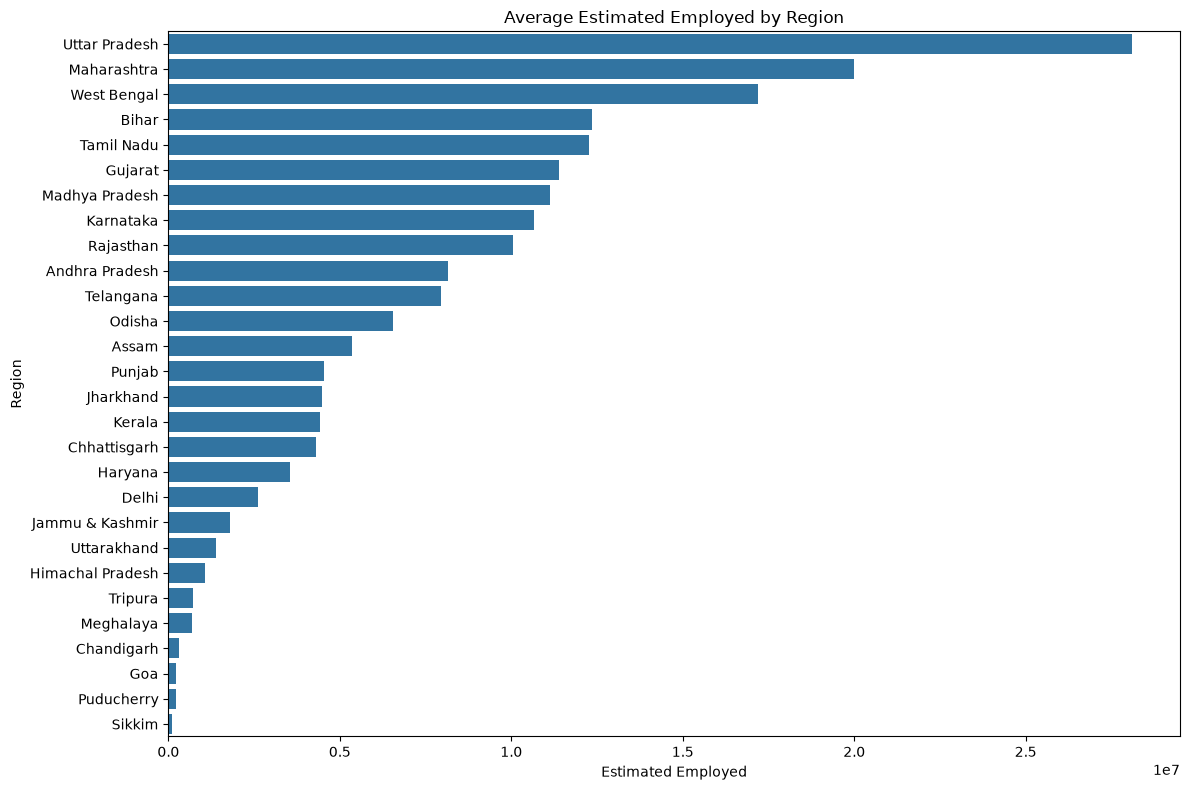

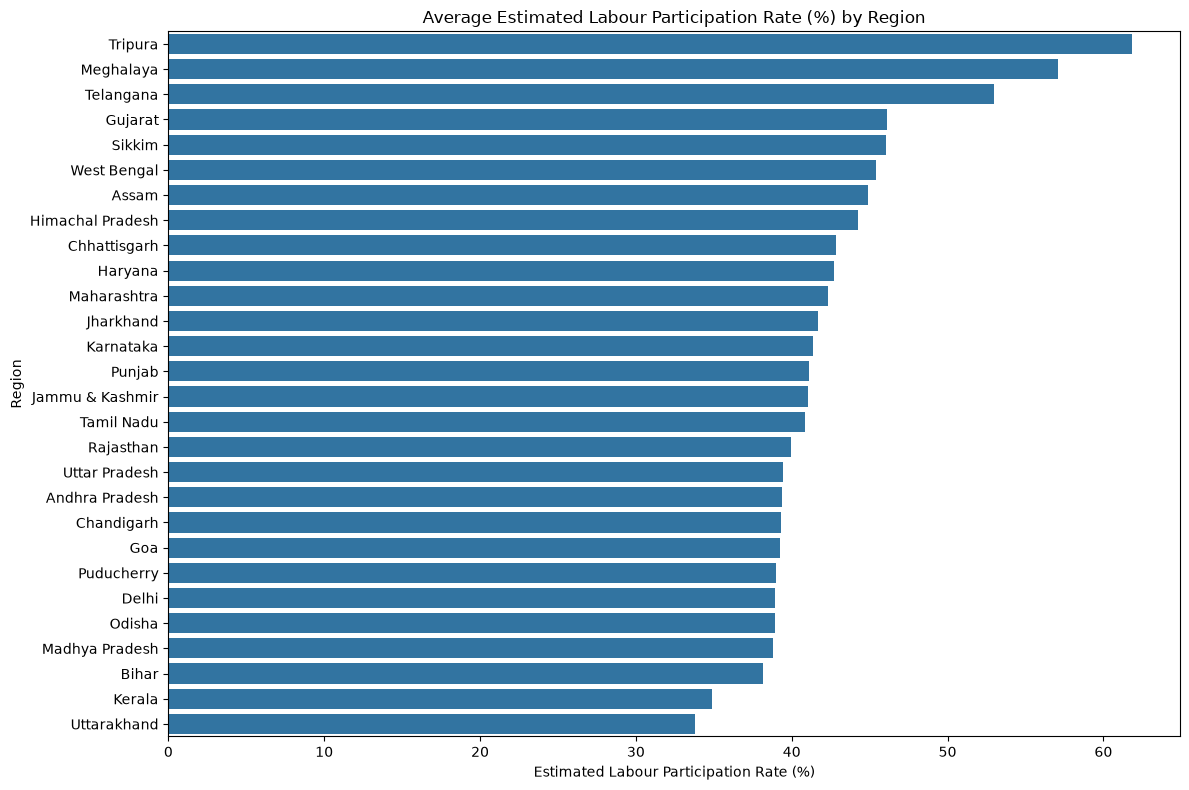

In [413]:
cols = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)',
]

for i in cols:

    plt.figure(figsize=(12, 8))

    top = (
        df_copy.groupby("Region")[i]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    sns.barplot(
        data=top,
        x=i,
        y="Region"
    )

    plt.title(f"Average {i} by Region")
    plt.tight_layout()

plt.show()

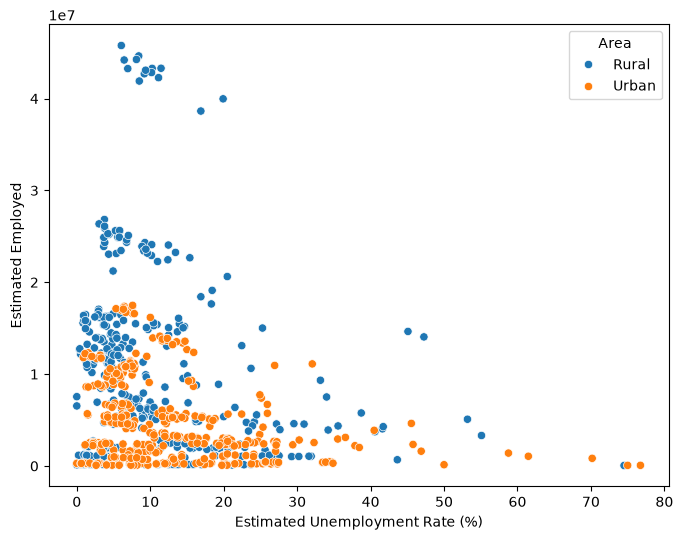

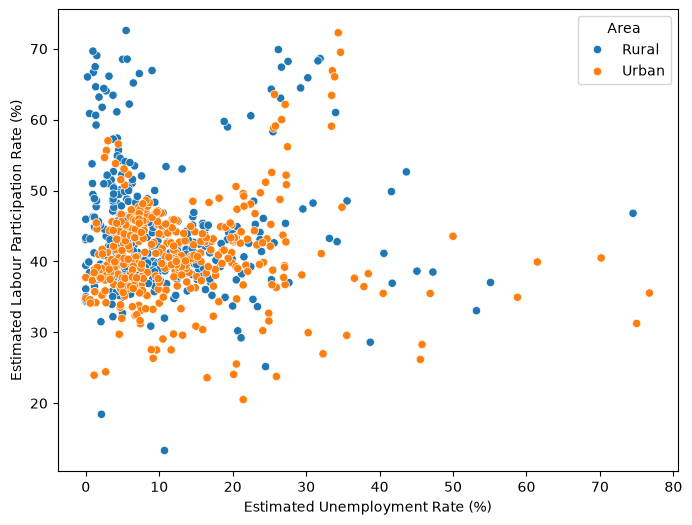

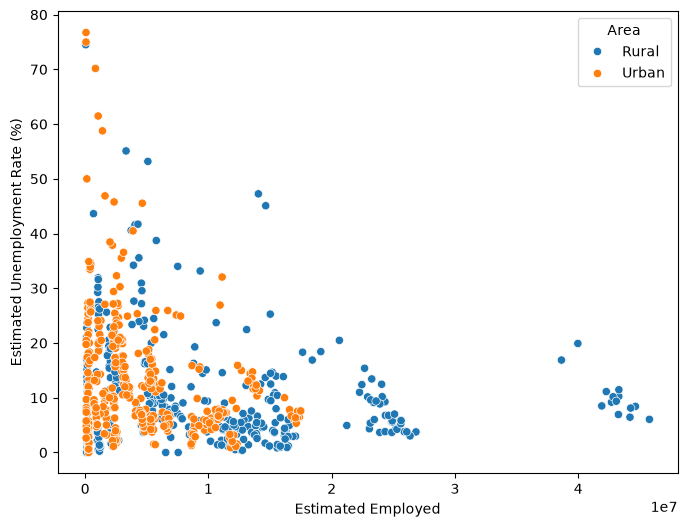

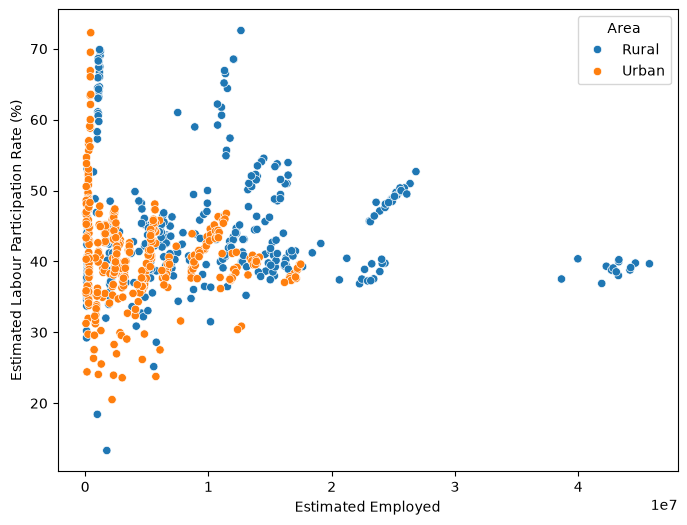

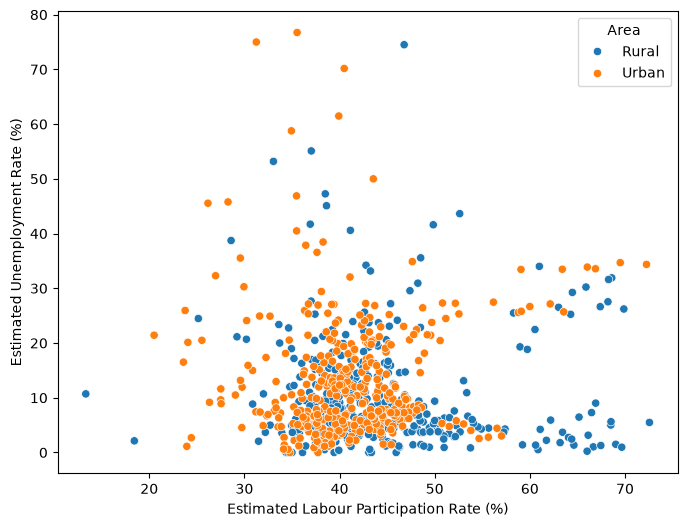

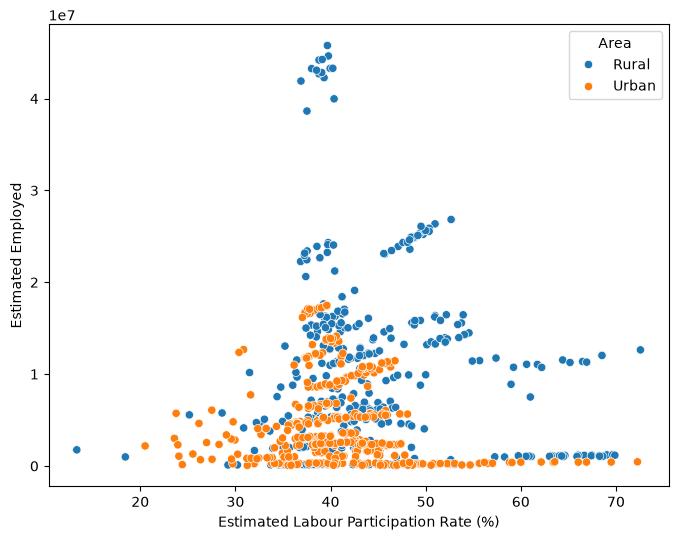

In [414]:
cols = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)',
]

for i in cols:
    for j in cols:
        if i != j:
            plt.figure(figsize=(8,6))
            sns.scatterplot(
                x=i,
                y=j,
                data=df_copy,
                hue="Area"
            )

plt.show()

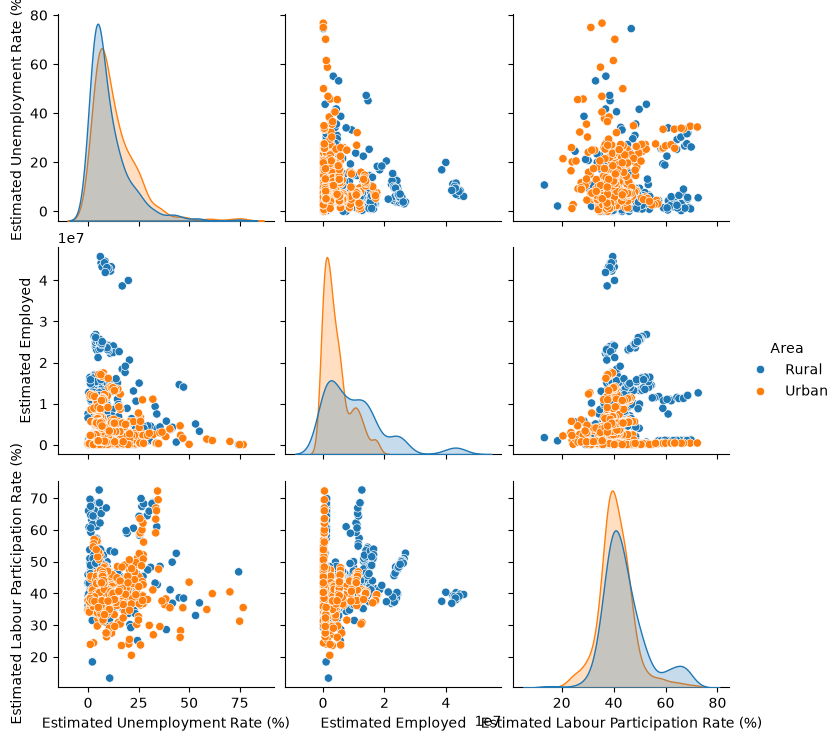

In [415]:
sns.pairplot(
    df_copy,
    vars=[
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ],
    hue="Area"
)

plt.show()

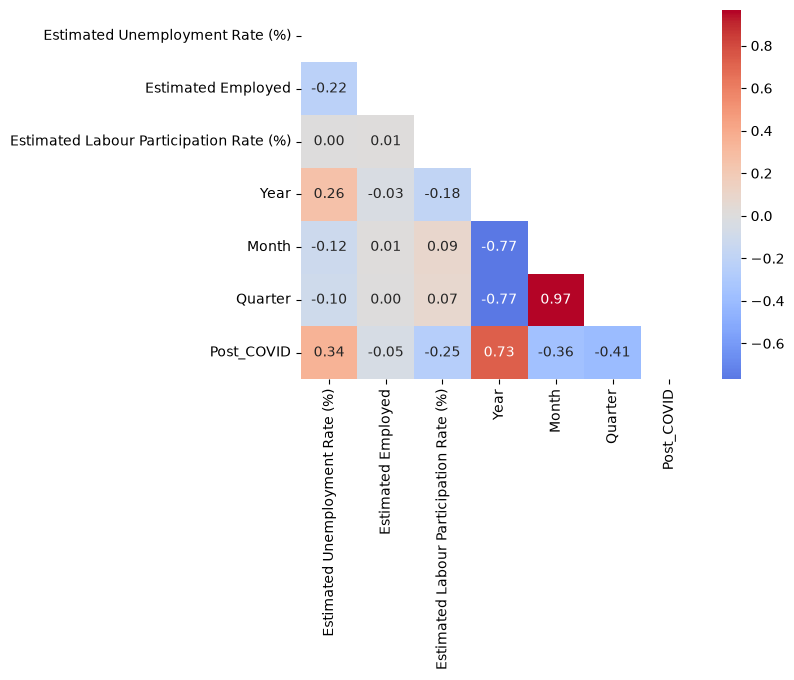

In [416]:
corr = df_copy.select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    mask=mask,
    center=0
)
plt.show()